In [10]:
import sys
!{sys.executable} -m pip install torch

   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.8/114.6 MB 2.2 MB/s eta 0:00:52
    --------------------------------------- 1.6/114.6 MB 3.0 MB/s eta 0:00:38
    --------------------------------------- 2.6/114.6 MB 3.3 MB/s eta 0:00:34
   - -------------------------------------- 3.9/114.6 MB 4.0 MB/s eta 0:00:28
   - -------------------------------------- 4.7/114.6 MB 4.1 MB/s eta 0:00:27
   -- ------------------------------------- 6.0/114.6 MB 4.4 MB/s eta 0:00:25
   -- ------------------------------------- 7.1/114.6 MB 4.6 MB/s eta 0:00:24
   --- ------------------------------------ 8.9/114.6 MB 5.0 MB/s eta 0:00:22
   --- ------------------------------------ 10.2/114.6 MB 5.2 MB/s eta 0:00:21
   ---- -----

In [7]:
import numpy as np

# 1. 创建形状 3x4 的随机矩阵 X，元素服从标准正态分布
np.random.seed(42)          # 固定随机种子，保证结果可重现
X = np.random.randn(3, 4)

# 2. 创建形状 4x2 的全1矩阵 Y
Y = np.ones((4, 2))

# 3. 计算矩阵乘法 Z = X @ Y
Z = X @ Y

# 4. 输出 Z 的第一行和第二列交叉处的元素，以及 Z 的第2行所有元素
print("Z 的第一行第二列元素:", Z[0, 1])
print("Z 的第二行所有元素:", Z[1, :])

# 5. 计算 Z 的 Frobenius 范数
fro_norm = np.linalg.norm(Z, 'fro')
print("Z 的 Frobenius 范数:", fro_norm)

Z 的第一行第二列元素: 2.5291682463487657
Z 的第二行所有元素: [1.87835721 1.87835721]
Z 的 Frobenius 范数: 4.616873319476864


c:\Users\DELL\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23494 (\N{CJK UNIFIED IDEOGRAPH-5BC6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\DELL\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\DELL\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\DELL\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24515 (\N{CJK UNIFIED IDEOGRAPH-5FC3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\DELL\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26497 (\N{CJK UNIFIED IDEOGRAPH-6781}) missing from font(s) DejaVu Sans.
  

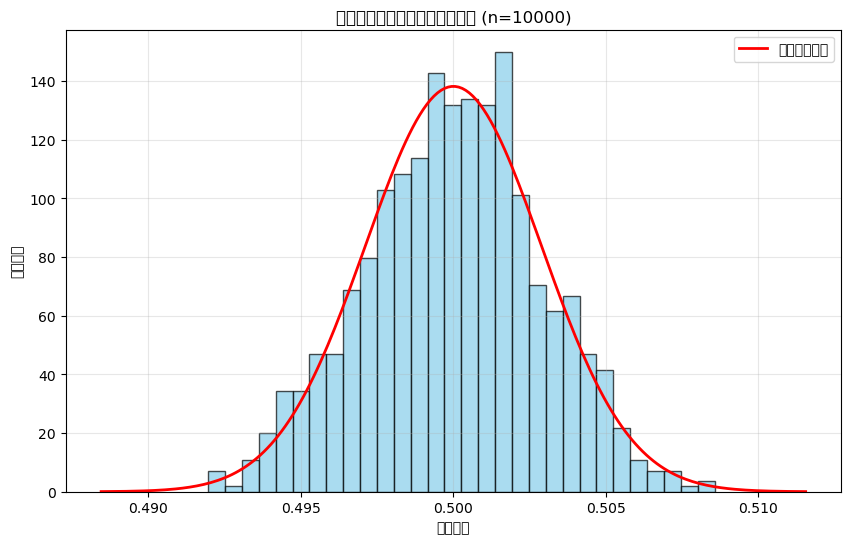

实际计算得到的均值方差: 0.000008
理论方差 (1/12)/10000 = 0.000008


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 参数设置
n = 10000       # 每个样本的随机变量个数
m = 1000        # 重复次数

# 1. 生成 m 个均值
means = []
for _ in range(m):
    samples = np.random.uniform(0, 1, n)
    means.append(np.mean(samples))

# 2. 绘制直方图 + 理论正态分布曲线
plt.figure(figsize=(10, 6))
plt.hist(means, bins=30, density=True, alpha=0.7, color='skyblue', edgecolor='black')

# 理论正态分布：均值 = 均匀分布的均值 0.5，方差 = 均匀分布方差 (1/12) / n
mu_theory = 0.5
sigma_theory = np.sqrt((1/12) / n)
x = np.linspace(mu_theory - 4*sigma_theory, mu_theory + 4*sigma_theory, 200)
plt.plot(x, norm.pdf(x, mu_theory, sigma_theory), 'r-', lw=2, label='理论正态分布')

plt.title('中心极限定理：样本均值的分布 (n=10000)')
plt.xlabel('样本均值')
plt.ylabel('概率密度')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 3. 计算这些均值的实际方差
actual_var = np.var(means)
print(f"实际计算得到的均值方差: {actual_var:.6f}")
print(f"理论方差 (1/12)/{n} = {(1/12)/n:.6f}")

In [11]:
import torch

# 给定参数
x = 2.0
w1 = 1.5
w2 = 0.5

# ---------- 手动计算前向 ----------
a = x * w1
b = a + w2
L = b ** 2
print(f"前向计算结果: L = {L}")

# ---------- 手动计算梯度（链式法则）----------
# dL/db = 2*b
# db/dw1 = x,   db/dw2 = 1
# dL/dw1 = dL/db * db/dw1 = 2*b * x
# dL/dw2 = dL/db * db/dw2 = 2*b * 1
b_val = b
grad_w1_manual = 2 * b_val * x
grad_w2_manual = 2 * b_val * 1
print(f"手动计算梯度: dL/dw1 = {grad_w1_manual}, dL/dw2 = {grad_w2_manual}")

# ---------- 使用 PyTorch 自动微分验证 ----------
x_t = torch.tensor(x, requires_grad=False)
w1_t = torch.tensor(w1, requires_grad=True)
w2_t = torch.tensor(w2, requires_grad=True)

a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t ** 2
L_t.backward()

print(f"PyTorch 自动微分: dL/dw1 = {w1_t.grad.item()}, dL/dw2 = {w2_t.grad.item()}")

前向计算结果: L = 12.25
手动计算梯度: dL/dw1 = 14.0, dL/dw2 = 7.0
PyTorch 自动微分: dL/dw1 = 14.0, dL/dw2 = 7.0


In [ ]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# ---------- 1. 加载数据 ----------
digits = load_digits()
X = digits.data          # (1797, 64)
y = digits.target.reshape(-1, 1)   # (1797, 1)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 归一化（提升数值稳定性）
X_train = X_train / 16.0
X_test = X_test / 16.0

# ---------- 2. One-hot 编码标签 ----------
encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = encoder.fit_transform(y_train)
y_test_onehot = encoder.transform(y_test)
num_classes = y_train_onehot.shape[1]

# ---------- 3. 定义 Softmax 和交叉熵损失 ----------
def softmax(logits):
    exp_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true):
    # y_pred: (n, C), y_true: (n, C) one-hot
    n = y_pred.shape[0]
    loss = -np.sum(y_true * np.log(y_pred + 1e-8)) / n
    return loss

# ---------- 4. 小批量 SGD 训练 ----------
batch_size = 32
lr = 0.1
epochs = 50
n_train = X_train.shape[0]
input_dim = X_train.shape[1]

# 初始化权重和偏置
W = np.random.randn(input_dim, num_classes) * 0.01
b = np.zeros((1, num_classes))

for epoch in range(epochs):
    # 每个 epoch 打乱数据
    indices = np.random.permutation(n_train)
    X_shuffled = X_train[indices]
    y_shuffled = y_train_onehot[indices]
    
    epoch_loss = 0.0
    for i in range(0, n_train, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        
        # 前向传播
        logits = X_batch @ W + b
        probs = softmax(logits)
        loss = cross_entropy_loss(probs, y_batch)
        epoch_loss += loss
        
        # 反向传播（梯度计算）
        n_batch = X_batch.shape[0]
        dlogits = probs - y_batch          # (n_batch, C)
        dW = (X_batch.T @ dlogits) / n_batch
        db = np.mean(dlogits, axis=0, keepdims=True)
        
        # 参数更新
        W -= lr * dW
        b -= lr * db
        
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, 平均损失: {epoch_loss / (n_train//batch_size + 1):.4f}")

# ---------- 5. 测试准确率 ----------
logits_test = X_test @ W + b
probs_test = softmax(logits_test)
y_pred = np.argmax(probs_test, axis=1)
y_true = np.argmax(y_test_onehot, axis=1)
accuracy = np.mean(y_pred == y_true)
print(f"\n测试集准确率: {accuracy * 100:.2f}%")

Epoch 10/50, 平均损失: 0.4566
Epoch 20/50, 平均损失: 0.3003
Epoch 30/50, 平均损失: 0.2413
Epoch 40/50, 平均损失: 0.2077
Epoch 50/50, 平均损失: 0.1859

测试集准确率: 96.39%


Iter 200, Loss = 0.3446
Iter 400, Loss = 0.3375
Iter 600, Loss = 0.3341
Iter 800, Loss = 0.3321
Iter 1000, Loss = 0.3308


c:\Users\DELL\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\DELL\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\DELL\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36923 (\N{CJK UNIFIED IDEOGRAPH-903B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\DELL\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36753 (\N{CJK UNIFIED IDEOGRAPH-8F91}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\DELL\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22238 (\N{CJK UNIFIED IDEOGRAPH-56DE}) missing from font(s) DejaVu Sans.
  

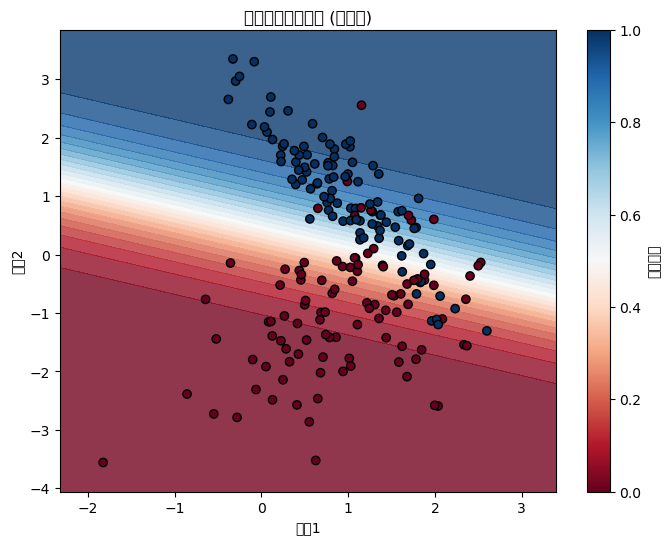


测试集准确率: 88.00%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

# ---------- 1. 生成线性可分数据 ----------
np.random.seed(0)
X, y = make_classification(n_samples=400, n_features=2, n_redundant=0,
                           n_clusters_per_class=1, flip_y=0, random_state=42)
# 将标签转为 0/1
y = y.reshape(-1, 1)

# 划分训练集（前200个）和测试集（后200个），但为了符合题目“每类200个”，这里确保每类各200
# make_classification 已经大致平衡，我们取前200为训练，后200为测试（按顺序）
X_train, X_test = X[:200], X[200:]
y_train, y_test = y[:200], y[200:]

# ---------- 2. 定义 Sigmoid 和二元交叉熵损失 ----------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_pred, y_true):
    # y_pred: 预测概率, y_true: 0/1
    eps = 1e-8
    return -np.mean(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps))

# ---------- 3. 梯度下降训练 ----------
lr = 0.1
iterations = 1000
n_samples, n_features = X_train.shape

# 初始化参数
W = np.zeros((n_features, 1))
b = 0.0

losses = []
for i in range(iterations):
    # 前向传播
    logits = X_train @ W + b
    y_pred = sigmoid(logits)
    
    # 损失
    loss = binary_cross_entropy(y_pred, y_train)
    losses.append(loss)
    
    # 梯度计算
    dw = (X_train.T @ (y_pred - y_train)) / n_samples
    db = np.mean(y_pred - y_train)
    
    # 参数更新
    W -= lr * dw
    b -= lr * db
    
    if (i+1) % 200 == 0:
        print(f"Iter {i+1}, Loss = {loss:.4f}")

# ---------- 4. 绘制决策边界 ----------
# 生成网格点
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
probs = sigmoid(grid @ W + b).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, probs, levels=25, alpha=0.8, cmap='RdBu')
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train.ravel(), edgecolors='k', cmap='RdBu')
plt.title('逻辑回归决策边界 (训练集)')
plt.xlabel('特征1')
plt.ylabel('特征2')
plt.colorbar(label='预测概率')
plt.show()

# 计算测试集准确率
y_test_pred_prob = sigmoid(X_test @ W + b)
y_test_pred = (y_test_pred_prob >= 0.5).astype(int)
accuracy = np.mean(y_test_pred == y_test)
print(f"\n测试集准确率: {accuracy * 100:.2f}%")